In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

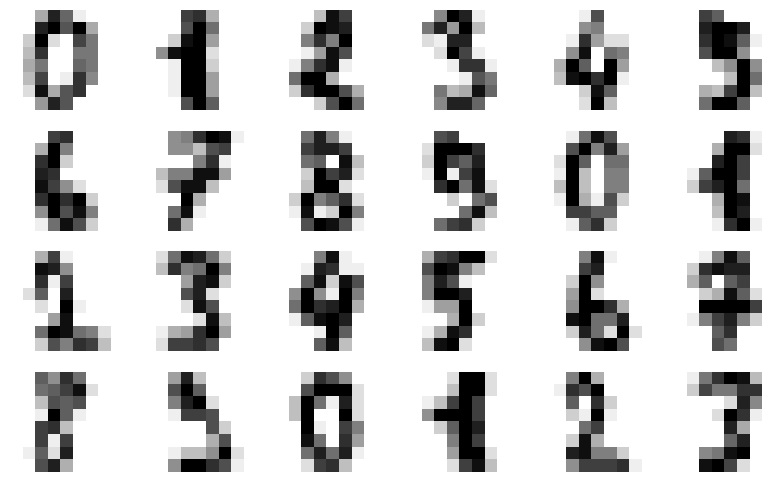

In [2]:
digits = load_digits()

fig, axes = plt.subplots(4, 6, figsize=(10, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r)
    ax.axis('off')
plt.show()

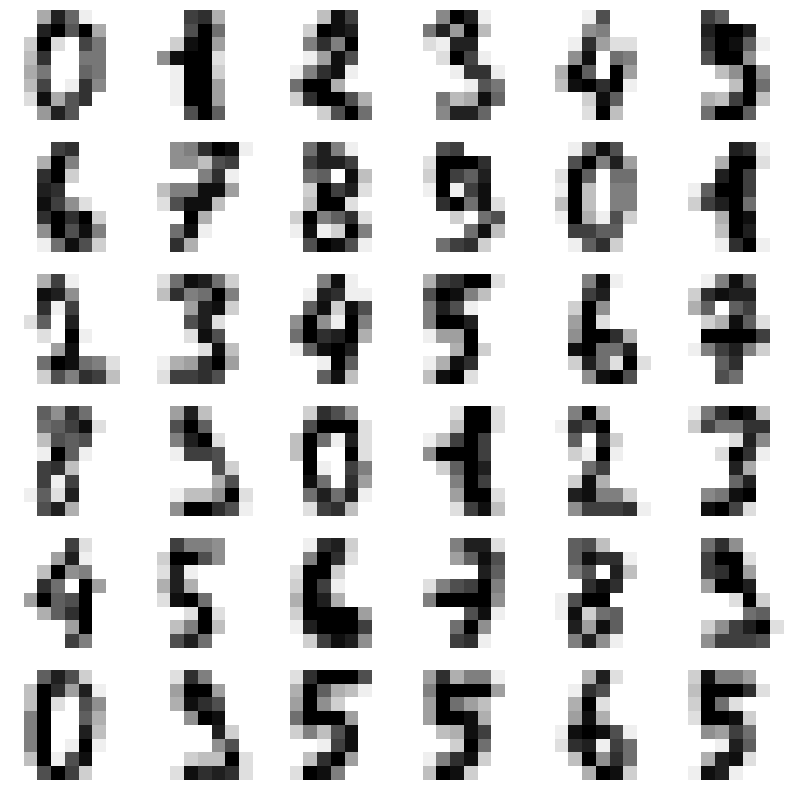

In [3]:
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r)
    ax.axis('off')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, 
    digits.target, 
    test_size=0.20,
    random_state=11)

display(X_train.shape)
display(X_test.shape)

(1437, 64)

(360, 64)

In [ ]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_df, annot=True, cmap='nipy_spectral_r')
    plt.show()

### Step 1: Hyperparameter Tuning (GridSearchCV)
We will optimize both the `KNeighborsClassifier` and `SVC` using `GridSearchCV`. 
For KNN, the maximum $k$ is dynamically calculated as the square root of the number of training samples, and we only test odd values to prevent tie-breaking ambiguity. We'll also use cell magics (`%%time`) to track the execution time.

In [ ]:
%%time
import math

# Calculate dynamic limit for k
max_k = int(math.sqrt(X_train.shape[0]))
odd_k_values = [k for k in range(1, max_k + 1) if k % 2 != 0]

knn_params = {
    'n_neighbors': odd_k_values,
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)


In [ ]:
%%time
svc_params = {
    'C': [0.1, 1, 10, 100], 
    'gamma': [0.0001, 0.001, 0.01, 0.1], 
    'kernel': ['rbf', 'poly', 'linear']
}

grid_svc = GridSearchCV(SVC(), svc_params, cv=5, n_jobs=-1)
grid_svc.fit(X_train, y_train)

print("Best SVC parameters:", grid_svc.best_params_)


### Step 2: Comparison of Optimized Models
Here we compare the cross-validation scores (`best_score_`) of our optimized KNN and SVC models alongside a baseline `GaussianNB` model. 

*Note on Execution Time:* When choosing between KNN and SVC, time complexity is a key factor. KNN is a "lazy learner"—it has zero training time but is slow during inference because it compares distance to all samples. SVC takes longer to train initially, but inference is generally much faster as it only relies on the support vectors.

In [ ]:
from sklearn.model_selection import cross_val_score

best_knn = grid_knn.best_estimator_
best_svc = grid_svc.best_estimator_

nb_score = cross_val_score(GaussianNB(), X_train, y_train, cv=5).mean()

comparison_df = pd.DataFrame({
    'Model': ['Optimized KNN', 'Optimized SVC', 'Baseline GaussianNB'],
    'CV Accuracy': [grid_knn.best_score_, grid_svc.best_score_, nb_score]
})

display(comparison_df.sort_values(by='CV Accuracy', ascending=False))


### Step 3: Deep Diagnostics
Using the absolute best model from Step 2, we will now evaluate its performance on the unseen test set `X_test`. We'll generate a classification report and plot the confusion matrix using Seaborn.

In [ ]:
# Identify the absolute best model
best_overall_model = best_svc if grid_svc.best_score_ > grid_knn.best_score_ else best_knn
print(f"Absolute Best Model: {best_overall_model.__class__.__name__}")

# Predict and report
y_pred = best_overall_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Plot confusion matrix using your existing function
plot_confusion_matrix(y_test, y_pred)
